### ISC0 -- Computer works #5 -- 2025
### Emulation of Physics-Informed Neural Networks (PINNs)

In this Notebook, we are going to solve Ordinary Differential Equations (ODEs) in the philosophy of Physics-Informed Neural Networks (PINNs).

Consider the differential problem:

\begin{align*}
& \frac{d u(t)}{dt} = f(u(t),t),\qquad t\in [0,T],\\[1.3ex]
& u(0) = u_0 \quad (\text{initial condition, given}).
\end{align*}

In PINNs, is it assumed that the differential equations of the
physical problem are known.

The solution $\big(u(t)\big)_{t\in[0,T]}$ is approximated with a Deep Neural Network (DNN). 

Then the coefficients (weighting matrices and biases vectors) are optimized in order to minimize the residuals of the differential equations: for $m$ time samples $t^i$ (called collocation points) chosen randomly in the time interval
$[0,T]$, a residual loss function $\mathcal{L}_r$ is defined as

$$
\mathcal{L}_r = \frac{1}{2} \frac{1}{m} \sum_{i=1}^m \Big( \frac{d u}{dt}(t^i) - f(u(t^i),t^i) \Big)^2.
$$

The total loss function is the weighted sum of the residual loss function and the loss related to the initial condition:

$$
\mathcal{L} = \mathcal{L}_r + \frac{\omega}{2} \big(u(0)-u_0\big)^2,
$$

where $\omega>0$ is a weight coefficient.

#### Emulation of the Neural Network

Rather than considering a true NN for modeling $u(t)$, we consider a linear combination of polynomials of low order and sine-type 'activation' functions:

$$
u(t) = \alpha + \beta\, (t/T) + \gamma\, (t/T)^2 + \sum_{k=1}^K \left\{ a_k \cos(2k\pi t/T) + b_k \sin(2 k\pi t/T) \right\},
$$

and the coefficients $\alpha$, $\beta$, $\gamma$ and $(a_k)_k$ and $(b_k)_k$ are the parameters to optimize. Here, the search space is of dimension $(2K+3)$.

### Ex 1 - Linear differential equation

Consider the linear differential problem

\begin{align*}
& \dot u(t) = -\lambda\, u(t),\quad t\in[0,T], \\
& u(0) = 1,
\end{align*}

where $\lambda = 0.4$, $T=10$. The exact solution has the analytical expression

$$
u(t) = \exp(-\lambda t).
$$

Plot the solution in the interval $[0,T]$.

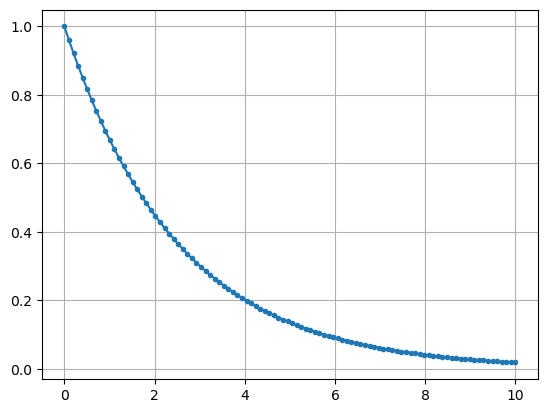

In [3]:
import numpy as np
import matplotlib.pyplot as plt
u0 = 1.0
lambd = 0.4
T = 10.0
m = 100
t = np.linspace(0, T, m)
plt.plot(t, np.exp(-lambd*t), '.-'); plt.grid()

#### Approximation function

First, show that the exact solution $u(t)$ can be well approximated by the pseudo-neural network using $K=4$ and a least-square approach.

The approximate solution will be denoted by $\tilde u(t)$. Solve the least square problem. Print the vector 
of optimal parameters (denoted by $\mathbf{w}$).

In [4]:
# u(t) = \alpha + \beta\, (t/T) + \gamma\, (t/T)^2 
# + \sum_{k=1}^K \left\{ a_k \cos(2k\pi t/T) + b_k \sin(2 k\pi t/T) \right\},

# Least square problem
K = 4
A = np.zeros((m,2*K+3))
A[:,0] = 1.0
A[:,1] = t/T
A[:,2] = (t/T)**2
for k in range(K):
    A[:,3+k]   = np.cos(2*(k+1)*np.pi*(t/T))
    A[:,3+K+k] = np.sin(2*(k+1)*np.pi*(t/T))
y = np.exp(-lambd*t)
w = np.linalg.solve(A.T@A, A.T@y)

In [5]:
print("w = \n", w)

w = 
 [ 1.05763948e+00 -2.91996329e+00  1.94329528e+00 -5.53341883e-02
 -4.06323713e-03 -7.22787376e-04 -1.76348032e-04 -8.85230948e-02
 -1.35766983e-02 -3.95770554e-03 -1.53283938e-03]


Write a function `utilde(t,w)` that computes $\tilde u(t)$. Then plot the function $t\mapsto \tilde u(t)$ and compare to the 
exact solution of the differential problem.

Plot also the error function $t\mapsto e(t):=u(t)-\tilde u(t)$.

In [6]:
def utilde(t, w):
    alpha, beta, gama = w[0:3]
    ak = w[3:3+K]
    bk = w[3+K:3+2*K]
    ut = alpha + beta*(t/T) + gama*(t/T)**2
    for k in range(0, K):
        ut += ak[k]*np.cos(2*(k+1)*np.pi*(t/T)) + bk[k]*np.sin(2*(k+1)*np.pi*(t/T))
    return ut

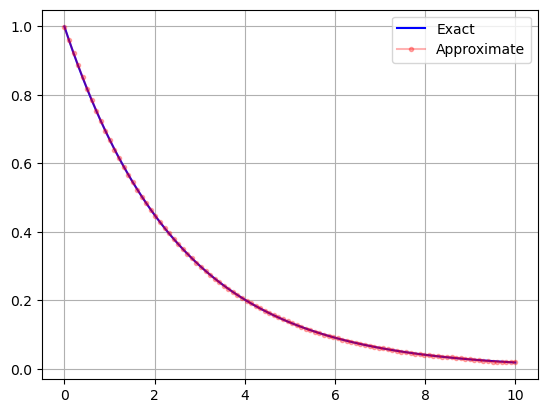

In [7]:
plt.plot(t, y, 'b-')
plt.plot(t, utilde(t,w), '.-r', alpha=0.3); plt.grid()
plt.legend(['Exact', 'Approximate'])

### PINN Loss function definition

Next, write a function `Loss(w,t)` that computes the loss function defined above with the discrete time array `t` and the
parameter vector `w`. For the weight coefficient $\omega$, use $\omega=10$.

In [8]:
# dudt += beta/T + gama*(2*t/(T**2) \
#      - ak[k]*(2*(k+1)*np.pi/T)*np.sin(2*(k+1)*np.pi*(t/T)) \
#      + bk[k]*(2*(k+1)*np.pi/T)*np.cos(2*(k+1)*np.pi*(t/T))

def dudt(t, w):
    alpha, beta, gama = w[0:3]
    ak = w[3:3+K]
    bk = w[3+K:3+2*K]
    udot = beta/T + gama*(2*t/(T**2))
    for k in range(0, K):
        udot += (2*(k+1)*np.pi/T)*( -ak[k]*np.sin(2*(k+1)*np.pi*(t/T)) + bk[k]*np.cos(2*(k+1)*np.pi*(t/T)) )
    return udot
    
def Loss(w,t):
    lamb  = 0.4
    omega = 10.0
    m = t.size
    # First compute the residual loss function
    Lr = 0.0
    for i in range(m):
        Lr += (0.5/m)*( dudt(t[i],w) + lambd * utilde(t[i],w) )**2
    # Then add the loss related to the initial condition
    Losstot = Lr + 0.5*omega*(utilde(0,w) - 1.0)**2
    return Losstot

In [9]:
print( Loss(w,t) )

4.462389212085215e-05


Then use `scipy.optimize.minimize()` to minimize the loss function and get the optimal parameter vector.
Compare the parameter vector `wpinn` found by the PINN minimization problem to the vector $\mathbf{w}$ of the
least-square approximation problem.

Compare also the values of the loss functions for both `wpinn` and `w`.

In [10]:
from scipy.optimize import minimize

w0 = np.zeros(11)
res = minimize(Loss, w0, method='BFGS', args=(t))
wpinn = res.x

In [11]:
print(wpinn, "\n",w)

[ 1.06141205e+00 -2.93224093e+00  1.94989862e+00 -5.61048345e-02
 -4.26241312e-03 -8.16309191e-04 -2.30231472e-04 -9.05696334e-02
 -1.46363677e-02 -4.66866559e-03 -2.06812695e-03] 
 [ 1.05763948e+00 -2.91996329e+00  1.94329528e+00 -5.53341883e-02
 -4.06323713e-03 -7.22787376e-04 -1.76348032e-04 -8.85230948e-02
 -1.35766983e-02 -3.95770554e-03 -1.53283938e-03]


In [12]:
print( Loss(wpinn,t) )

7.1929209201136674e-06


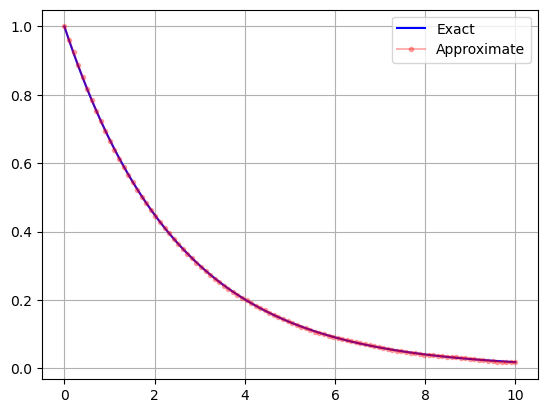

In [13]:
plt.plot(t, y, 'b-')
plt.plot(t, utilde(t,wpinn), '.-r', alpha=0.3); plt.grid()
plt.legend(['Exact', 'Approximate']);

### Ex 2 - Nonlinear differential equation

Let us now deal with nonlinear equations. Consider the differential problem

\begin{align*}
& \dot u(t) = -\lambda\, u^2(t),\quad t\in [0,T] \\
& u(0) = 1,
\end{align*}

where $\lambda = 0.4$, $T=10$. The exact solution has the analytical expression

$$
u(t) = \frac{1}{1+\lambda\, t}.
$$

Again, show that the exact solution $u(t)$ can be well approximated by the neural network using $K=4$.
The approximate solution will be denoted by $\tilde u(t)$.

In [14]:
# Least square problem
K = 4
A = np.zeros((m,2*K+3))
A[:,0] = 1.0
A[:,1] = t/T
A[:,2] = (t/T)**2
for k in range(K):
    A[:,3+k]   = np.cos(2*(k+1)*np.pi*(t/T))
    A[:,3+K+k] = np.sin(2*(k+1)*np.pi*(t/T))
y = 1.0 / (1+lambd*t)
w = np.linalg.solve(A.T@A, A.T@y)

In [15]:
w

array([ 1.10081785e+00, -2.60902646e+00,  1.81819172e+00, -9.16688264e-02,
       -1.11838779e-02, -2.55394305e-03, -7.18976979e-04, -7.76172903e-02,
       -1.68810796e-02, -5.85506127e-03, -2.49772913e-03])

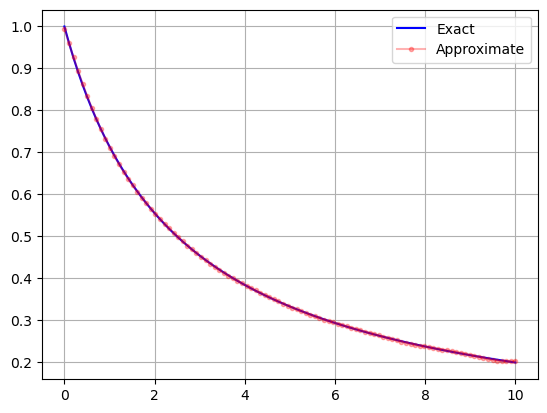

In [16]:
plt.plot(t, y, 'b-')
plt.plot(t, utilde(t,w), '.-r', alpha=0.3); plt.grid()
plt.legend(['Exact', 'Approximate'])

Next, define a loss function `Loss2(w,t)` for this problem. The minimize the loss function by using again
`scipy.optimize.minimize()`.

In [17]:
def Loss2(w,t):
    lamb  = 0.4
    omega = 10.0
    m = t.size
    # First compute the residual loss function
    Lr = 0.0
    for i in range(m):
        Lr += (0.5/m)*( dudt(t[i],w) + lambd * (utilde(t[i],w))**2 )**2
    # Then add the loss related to the initial condition
    Losstot = Lr + 0.5*omega*(utilde(0,w) - 1.0)**2
    return Losstot

In [18]:
print( Loss(w,t) )

0.0035945028519244826


In [19]:
from scipy.optimize import minimize

w0 = np.zeros(11)
res = minimize(Loss2, w0, method='BFGS', args=(t))
wpinn = res.x

Print the vector of parameters, the value of the loss function. Then plot the approximate solution and compare to the exact solution.

In [20]:
print(wpinn, "\n",w)

[ 1.11317396e+00 -2.66441478e+00  1.86311396e+00 -9.64775073e-02
 -1.24667767e-02 -3.16023782e-03 -1.08467490e-03 -8.13061499e-02
 -1.87969037e-02 -7.15833442e-03 -3.49173979e-03] 
 [ 1.10081785e+00 -2.60902646e+00  1.81819172e+00 -9.16688264e-02
 -1.11838779e-02 -2.55394305e-03 -7.18976979e-04 -7.76172903e-02
 -1.68810796e-02 -5.85506127e-03 -2.49772913e-03]


In [21]:
print( Loss(wpinn,t) )

0.003389878864654017


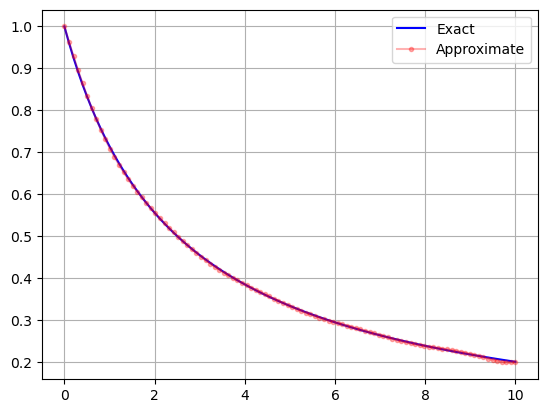

In [23]:
plt.plot(t, y, 'b-')
plt.plot(t, utilde(t,wpinn), '.-r', alpha=0.3); plt.grid()
plt.legend(['Exact', 'Approximate']);

### Ex 3 - Non-linear differential system: Lotka-Volterra system

Try to do the same exercise for the Lotka-Volterra system:

\begin{align*}
& \dot u(t) = (1-v(t))\, u(t), \\
& \dot v(t) = (u(t)-1)\, v(t),\qquad t\in[0,T],
\end{align*}

with initial condition $(u(0), v(0)) = (4,1)$. Use  $T=8.05$. Once the differential problem is solved, also plot
the invariant quantity

$$
\eta(t) = u(t) - \ln u(t) + v(t) - \ln v(t).
$$

In [46]:
from scipy.integrate import odeint

def Lotka(X,t):
    u, v = X
    f1 = (1-v)*u
    f2 = (u-1)*v
    return np.array([f1,f2])

X0 = np.array([4.0,1.0])
T = 8.05
t = np.linspace(0, T, 200)
Xsol = odeint(Lotka, X0, t)
Xsol = Xsol.T

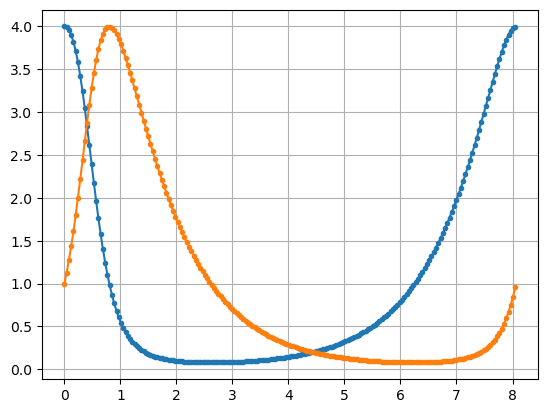

In [47]:
plt.plot(t, Xsol[0,:], '.-')
plt.plot(t, Xsol[1,:], '.-');plt.grid()